# Brazilian Ecommerce - Power BI + Data StoryTelling

En este entregable se construir un modelo dimensional en Power BI utilizando el dataset de olist (Brazilian Ecommerce) para diseñar un modelo DAR de 3 paginas y se desarrolla un historia basada en datos. El dataset incluye 9 tablas que permiten construir un star shcema completo.

En este notebook descansará es parte del proceso de auditoria de los datos, estudio de tipos, cardinalidad y rango temporal. Limpiaremos la data de ser necesario y se documentará el proceso llevado a cabo antes de dejar la data lista para ser importada a Power BI, evitando en la medida de lo posible la necesidad de realizar transformaciones adicionales en Power Query.

## 0. Load Data

Cargaremos los datos contenidos en `data/brazilian_ecommerce_dataset` utilizando la librería de pandas y veamos como esta la data incialmente. Se trata de varias tablas relacionadas entre si.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

pd.set_option('display.max_columns', None)

In [2]:
customers = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_orders_dataset.csv')
products = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_products_dataset.csv')
sellers = pd.read_csv('../data/brazilian_ecommerce_dataset/olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('../data/brazilian_ecommerce_dataset/product_category_name_translation.csv')

In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [4]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [5]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [6]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [7]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [9]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [10]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


## 1. Exploratory Data Analysis (EDA)

In [11]:
products['volume_l'] = (products['product_length_cm'] * products['product_width_cm'] * products['product_height_cm']) / 1000
products['weight_g'] = products['product_weight_g']
products['density_g_per_l'] = products['weight_g'] / products['volume_l']
products['density_g_per_l'] = products['density_g_per_l'].replace([np.inf, -np.inf], np.nan)
products['density_g_per_l'] = products['density_g_per_l'].fillna(0)

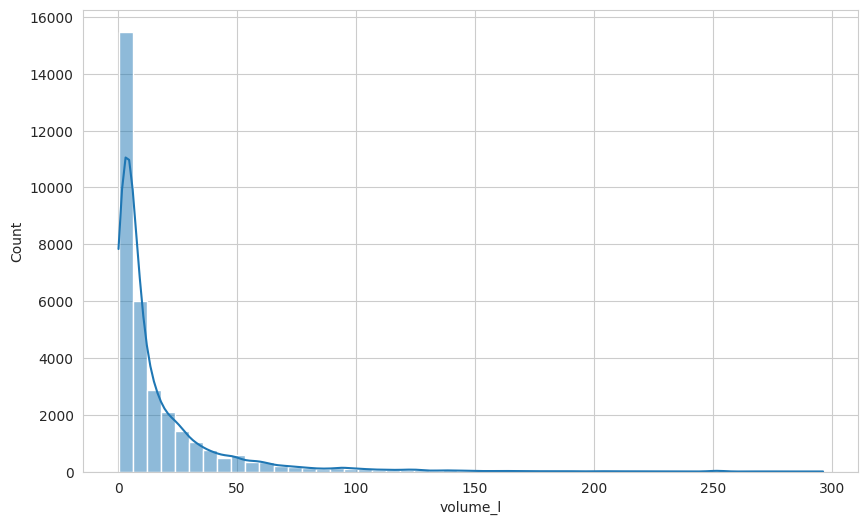

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(products['volume_l'], bins=50, kde=True)
plt.show()

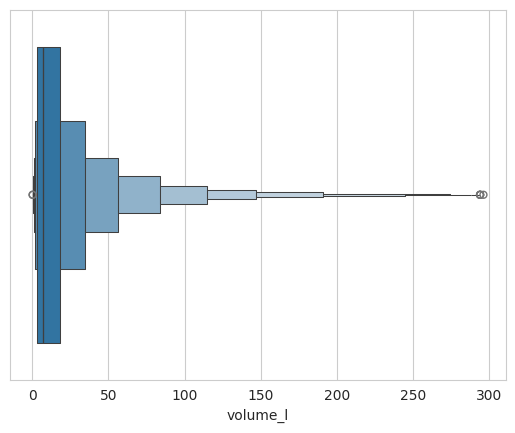

In [13]:
sns.boxenplot(x=products['volume_l'])
plt.show()

## 2. Hipothesis Testing for Data Storytelling

Se plantea la posibilidad de que la distancia entre el cliente y el vendedor tenga un impacto en el incumplimiento del SLA de entrega en función de un fallo en la estimación de fecha de entrega. Por tanto, que la planificación del SLA de entrega no se ajusta con la realidad conforme la distnacia de entrega empieza a ser mayor. Para esto se plantea la siguiente hipótesis:

- H0: La distancia entre el cliente y el vendedor no tiene impacto en el incumplimiento del SLA de entrega.
- H1: La distancia entre el cliente y el vendedor tiene impacto en el incumplimiento del SLA de entrega.

Para validar esto, priemro debemos calcular las distancias entre el cliente y el vendedor, y luego analizar la relación entre esta distancia y el incumplimiento del SLA de entrega. Para esto, se pueden seguir los siguientes pasos:

1. Calculamos la distancia de Haversine entre el cliente y el vendedor utilizando sus coordinadas geográficas (latitud y longitud).
2. Definimos una variable binaria que indique si el SLA de entrega fue incumplido o no, comparando la fecha de entrega estimada con la fecha de entrega real.
3. Construimos la varibale de dias de entrega estimada desde la orden de envio hasta la fecha de entrega estimada.
4. Graficamos la relación entre la distancia y lo dias estimados para la entrega, diferenciando el incumplimiento del SLA de entrega.
5. Calculamos la probabilidad de fallo del SLA en función de bins de distancia y vemos si existe una tendencia clara que indique que a mayor distancia, mayor es la probabilidad de incumplimiento del SLA de entrega.
6. Validamos o rechazamos la hipótesis nula $H_o$ en función del estudio estadístico mediante Chi-cuadrado o Información Mutua, o incluso mediante un modelo de regresión logística.

### 2.1 Construcción de variables necesarias para el análisis

Construimos la función de distancia de Haversine para calcular la distancia entre el cliente y el vendedor.

In [14]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # Earth radius in kilometers

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c= 2 * np.arcsin(np.sqrt(a))

    return c * R

Concatenamos la data en un unico DataFrame, para obtener toda la información necesaria para el análisis en un único lugar. Para ello, primero cruzamos data entre las ordenes, clientes y vendedores para despues concatenar la información de posicionamiento contenida en `geolocation`. Una vez hecho esto, ya si podemos calcular la distancia de Hervesine entre el cliente y el vendedor.

In [15]:
geo_distances =order_items[['order_id', 'seller_id']].merge(
    sellers[['seller_id', 'seller_zip_code_prefix']],
    on='seller_id',
    how='left'
).merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
).merge(
    customers[['customer_id', 'customer_zip_code_prefix']],
    on='customer_id',
    how='left'
)[['order_id', 'seller_id', 'customer_id', 'seller_zip_code_prefix', 'customer_zip_code_prefix']].merge(
    geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].median().reset_index(),
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).merge(
    geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].median().reset_index(),
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left',
    suffixes=('_seller', '_customer')
).assign(
    distance_km=lambda x: haversine(
        x['geolocation_lat_seller'], x['geolocation_lng_seller'],
        x['geolocation_lat_customer'], x['geolocation_lng_customer']
    )
)[['order_id', 'seller_id', 'customer_id', 'distance_km']].drop_duplicates(subset='order_id')
# geo_distances.to_csv('../data/brazilian_ecommerce_dataset/clean/geo_distances.csv', index=False)

Construimos las variables faltantes para el análisis, como la variable binaria de incumplimiento del SLA de entrega y la variable de dias estimados para la entrega.

In [16]:
# Build features for delivery performance analysis
orders_dist = orders.merge(geo_distances, on='order_id', how='left')
orders_dist['days_delivery_estimate'] = (pd.to_datetime(orders_dist['order_estimated_delivery_date']) - pd.to_datetime(orders_dist['order_purchase_timestamp'])).dt.days
orders_dist['SLA_failed'] = pd.to_datetime(orders_dist['order_estimated_delivery_date']) < pd.to_datetime(orders_dist['order_delivered_customer_date'])

Veamos al relación ahora entre la distancia y el incumplimiento del SLA de entrega.

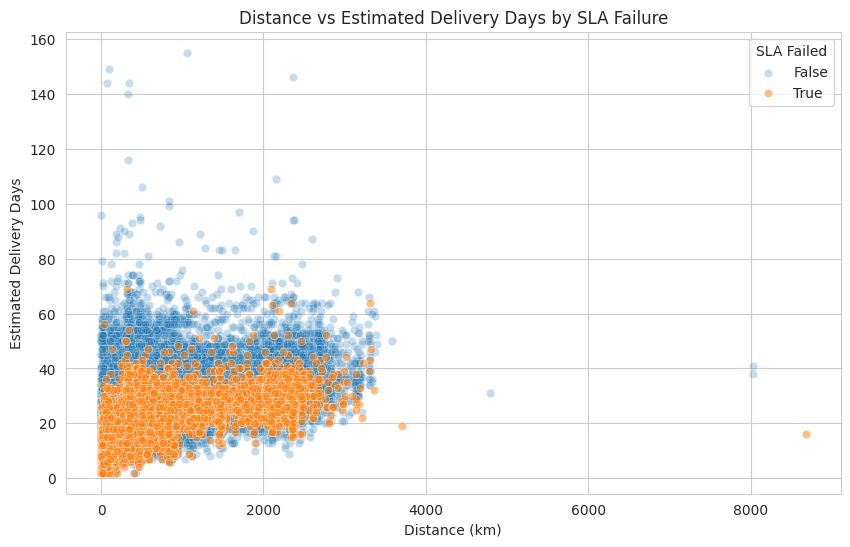

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette()

sns.scatterplot(
    data=orders_dist[~orders_dist['SLA_failed']],
    x='distance_km',
    y='days_delivery_estimate',
    ax=ax,
    alpha=0.25,
    color=palette[0],
    label='False'
)

sns.scatterplot(
    data=orders_dist[orders_dist['SLA_failed']],
    x='distance_km',
    y='days_delivery_estimate',
    ax=ax,
    alpha=0.5,
    color=palette[1],
    label='True'
)

plt.title('Distance vs Estimated Delivery Days by SLA Failure')
plt.xlabel('Distance (km)')
plt.ylabel('Estimated Delivery Days')
plt.legend(title='SLA Failed')

plt.show()


Parece haber cierta tendencia a que a mayor distancia, mayor probabilidad de incumplimiento del SLA de entrega. Ahora, es posible que los vendedores no estimen correctamente la fecha de entrega en función de la distancia y por eso vemos esa nube azul que solapa en el fondo mas arriba que la nube naranja, lo que nos hace intuir de que la media de los días estimados de entrega se encuentra mas arriba. En algunos casos, parece haber cierta sobre estimación. De cualquier manera, veamos esto en un boxplot para ver la tendencia central. 

Eso si, sin lugar a dudas parece ser necesario quitarnos algunos outliers tanto en distancia como en días estimados, pueden mover artificialmente la media. Retiramos los envios con distancias mayores a 4000 km y dias estimados superiores a 100 dias, que claramente no son casos comunes. Esto ayudará a limpiar mejor la data y evitar sesgos en la medición.

In [18]:
# Outliers
filtered_outliers = (orders_dist['distance_km'] > 4000) | (orders_dist['days_delivery_estimate'] > 100)

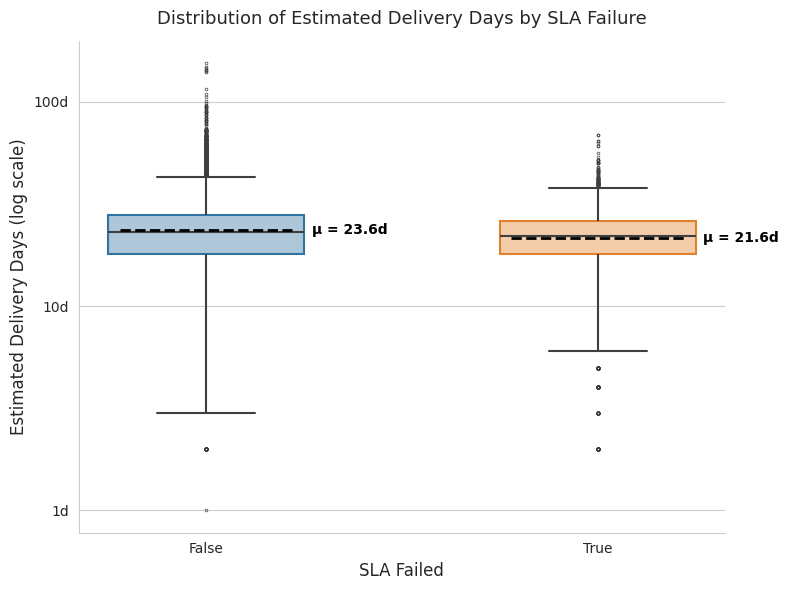

In [19]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 6))

data_box = orders_dist.dropna(subset=['days_delivery_estimate', 'SLA_failed']).copy()
data_box = data_box[data_box['days_delivery_estimate'] > 0]  # log scale requires > 0
data_box['SLA_failed_str'] = data_box['SLA_failed'].map({False: 'False', True: 'True'})
order = ['False', 'True']

sns.boxplot(
    data=data_box,
    x='SLA_failed_str',
    y='days_delivery_estimate',
    order=order,
    hue='SLA_failed_str',
    palette=[palette[0], palette[1]],
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker='o', markersize=2, linestyle='none', markeredgewidth=0.5),
    ax=ax,
    legend=False
)

# Semi-transparent fill, keep edge color
for patch in ax.patches:
    r, g, b, _ = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.4))
    patch.set_edgecolor((r, g, b, 1.0))

# Log scale on y axis
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, _: f'{int(val)}d'))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# Mean line + label per group (in data coords, works fine with log scale)
for i, sla_str in enumerate(order):
    sla_bool = sla_str == 'True'
    mean_val = data_box.loc[data_box['SLA_failed'] == sla_bool, 'days_delivery_estimate'].mean()
    ax.hlines(mean_val, i - 0.22, i + 0.22, colors='black', linewidths=2, linestyles='--', zorder=5)
    ax.text(i + 0.27, mean_val, f'μ = {mean_val:.1f}d', va='center', fontsize=10, fontweight='bold', color='black')

ax.set_title('Distribution of Estimated Delivery Days by SLA Failure', fontsize=13, pad=12)
ax.set_xlabel('SLA Failed', fontsize=12)
ax.set_ylabel('Estimated Delivery Days (log scale)', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


Podemos ver una diferencia en terminos de media en el ratio de SLA Failed, aunque este no parece ser tan grande. Para validar esto, vamos a visualizarlo en terminos de probabilidad para rangos determinados de distancia, para ver si existen diferencias claras en la probabilidad de incumplimiento del SLA de entrega a medida que aumenta la distancia entre el cliente y el vendedor.

In [20]:

# bins distances
bins = [0, 200, 500, 1000, 2000, 5000, 10000]
labels = ['0-200 km', '200-500 km', '500-1000 km', '1000-2000 km', '2000-5000 km', '5000-10000 km']

orders_dist['distance_bin'] = pd.cut(orders_dist['distance_km'], bins=bins, labels=labels)

# P(SLA_failed | distance_bin)
summary = orders_dist[~ filtered_outliers].groupby('distance_bin', observed=True).agg(
    n_orders =  ('order_id', 'count'),
    sla_fail_rate = ('SLA_failed', 'mean'),
    avg_estimate_days = ('days_delivery_estimate', 'median')
).reset_index()

print(summary)


   distance_bin  n_orders  sla_fail_rate  avg_estimate_days
0      0-200 km     25216       0.061469               15.0
1    200-500 km     30893       0.072573               22.0
2   500-1000 km     26285       0.082557               25.0
3  1000-2000 km      9956       0.105062               29.0
4  2000-5000 km      5788       0.132343               33.0


COnforme vemos como avabza la distancia, la probabilidad de incumplimiento del SLA de entrega parece aumentar, lo que nos hace intuir que la distancia entre el cliente y el vendedor tiene un impacto potencial sobre su cumplimiento. Como última fase de validación, vamos a realziar un estudio estadístico para comprobar si este cambio en el ratio es estadísticamente significativo y podemos o no rechazar la hipótesis nula $H_0$.

In [21]:
def chi2_summary(df, col_cat, col_binary, exclude_bins=None):
    """
    Full Chi-square summary for an ordinal categorical variable vs a binary variable.
    Includes: Chi², p-value, dof, Cramér's V, standardized residuals table
    and each category's contribution to the global statistic.
    """

    from scipy.stats import chi2_contingency

    data = df.copy()
    if exclude_bins:
        data = data[~data[col_cat].isin(exclude_bins)]

    # Contingency table
    ct = pd.crosstab(data[col_cat], data[col_binary])

    # Chi-square
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()

    # Cramér's V — normalized effect size (0=none, 1=perfect)
    k = min(ct.shape) - 1  # min(rows, columns) - 1
    cramers_v = np.sqrt(chi2 / (n * k))

    # Standardized residuals per cell: (O - E) / sqrt(E)
    # |r| > 2 = notable contribution, |r| > 3.5 = dominant contribution
    observed = ct.values
    std_residuals = (observed - expected) / np.sqrt(expected)
    residuals_df = pd.DataFrame(
        std_residuals,
        index=ct.index,
        columns=[f'residual_SLA={c}' for c in ct.columns]
    )

    # Each bin's contribution to the total Chi² (in %)
    contributions = ((observed - expected)**2 / expected)
    contrib_by_bin = contributions.sum(axis=1)  # sum across columns per row
    contrib_pct = pd.Series(
        100 * contrib_by_bin / chi2,
        index=ct.index,
        name='chi2_contribution_%'
    )

    # Observed SLA failure rate per bin
    fail_rate = data.groupby(col_cat, observed=True)[col_binary].mean().rename('sla_fail_rate')
    n_orders = data.groupby(col_cat, observed=True)[col_binary].count().rename('n_orders')

    # --- Output ---
    print("=" * 55)
    print("  CHI-SQUARE — FULL SUMMARY")
    print("=" * 55)
    print(f"  Chi²       = {chi2:>10.2f}")
    print(f"  p-value    = {p:>10.2e}  {'✅ Significant' if p < 0.05 else '❌ Not significant'}")
    print(f"  DoF        = {dof:>10d}")
    print(f"  N total    = {n:>10,}")
    print(f"  Cramér's V = {cramers_v:>10.4f}  {_interpret_cramers(cramers_v, k)}")
    print()
    print("  DETAIL BY BIN:")
    detail = pd.concat([n_orders, fail_rate, residuals_df, contrib_pct], axis=1)
    detail['sla_fail_rate'] = detail['sla_fail_rate'].map('{:.1%}'.format)
    detail['chi2_contribution_%'] = detail['chi2_contribution_%'].map('{:.1f}%'.format)
    print(detail.to_string())
    print("=" * 55)
    print("  Residuals |r| > 2.0 → notable contribution")
    print("  Residuals |r| > 3.5 → dominant contribution")

    return chi2, p, cramers_v, detail


def _interpret_cramers(v, k):
    """Cramér's V interpretation using Cohen's thresholds adjusted by dof."""
    # Standard thresholds for k=1 (minimum 2 categories)
    if k == 1:
        thresholds = [(0.10, 'small effect'), (0.30, 'medium effect'), (1.0, 'large effect')]
    else:  # k >= 2, lower thresholds
        thresholds = [(0.07, 'small effect'), (0.21, 'medium effect'), (1.0, 'large effect')]
    for t, label in thresholds:
        if v <= t:
            return f'→ {label}'
    return '→ large effect'


In [22]:
# Import libraries
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score


# ----- CHI-SQUARE TEST -----
chi2, p, cramers_v, detail = chi2_summary(orders_dist, col_cat='distance_bin', col_binary='SLA_failed', exclude_bins=['5000-10000 km'])

  CHI-SQUARE — FULL SUMMARY
  Chi²       =     446.36
  p-value    =   2.66e-95  ✅ Significant
  DoF        =          4
  N total    =     98,149
  Cramér's V =     0.0674  → small effect

  DETAIL BY BIN:
              n_orders sla_fail_rate  residual_SLA=False  residual_SLA=True chi2_contribution_%
distance_bin                                                                                   
0-200 km         25218          6.1%            2.936151         -10.011066               24.4%
200-500 km       30896          7.3%            1.216307          -4.147104                4.2%
500-1000 km      26287          8.3%           -0.565044           1.926567                0.9%
1000-2000 km      9957         10.5%           -2.687633           9.163721               20.4%
2000-5000 km      5791         13.2%           -4.208518          14.349313               50.1%
  Residuals |r| > 2.0 → notable contribution
  Residuals |r| > 3.5 → dominant contribution


Cómo primera observación, la significancia se alcanza con cierta facilidad debido a la catnidad de datos, por tanto lo importante es ver Cramer's V para ver la fuerza de la relación entre ambas variables. En este caso, el valor de Cramer's es de 0.067, lo qué es considerado un valor bajo, pero es un efecto real y monotónico y cuantificable. 

>La distancia no es el único driver que explica el incumplimiento del SLA de entrega, pero si es uun factor sistemático.

Lo interesante es como el residuo de los `SLA=True` va aumentando de valor conforme aumenta la distancia. Basicamente nos indica que el sistema predice que iba a fallar mucho menos he igualmente falló.

## 3. Data Cleaning

Como ya hicimos anteriormente, vamos a trabajar con distintas tablas para alimentar, limpiar y complementar el modelo dimensional que vamos a construir en Power BI. En este apartado, se alojaran punto por punto generaciones de datos complementarios, versiones de las tablas raw ya trabajadas y limpias o cualquier proceso adicional que pueda ser de interes.

### 3.1 Generación de tabla de distancias entre cliente y vendedor

Como ya hemos realizado un proceos de generación de la tabla de distancias entre clientes y vendedores, vamos a guardar esta tabla para poder importarla directamente a Power BI y evitar tener que realizar este proceso de cálculo en Power Query, lo que puede ser costoso en términos de tiempo de carga y rendimiento del modelo.

In [49]:
bins = [0, 200, 500, 1000, 2000, 5000, 10000]
labels = ['0-200 km', '200-500 km', '500-1000 km', '1000-2000 km', '2000-5000 km', '5000-10000 km']

sort_map = {
    '0-200 km':    1,
    '200-500 km':  2,
    '500-1000 km': 3,
    '1000-2000 km': 4,
    '2000-5000 km': 5,
    '5000-10000 km': 6
}

geo_distances['distance_bin'] = pd.cut(geo_distances['distance_km'], bins=bins, labels=labels)
geo_distances['distance_bin_sort'] = geo_distances['distance_bin'].map(sort_map)
geo_distances.to_csv('../data/brazilian_ecommerce_dataset/clean/geo_distances.csv', index=False)